In [56]:
from utils import *
from dipole import *
import pickle
import os
from scipy.optimize import curve_fit
import matplotlib as mpl
from lxml import etree
from collections import Counter
import hist
from hist import Hist
import numpy as np
import os 
from scipy.interpolate import interp1d
from scipy.stats import gamma

def calculate_corrected_upper_limits(raw_counts, efficiency, confidence_level=0.90):
    """
    Calculates the corrected upper limits for a trap histogram.
    
    Parameters:
    - raw_counts: numpy array of the raw (uncorrected) trap counts per bin
    - efficiency: numpy array of the detection efficiency per bin (0.0 to 1.0)
    - confidence_level: desired confidence level for the upper limit (e.g., 0.90 for 90% CL)
    
    Returns:
    - corrected_upper_limits: The efficiency-corrected upper limit array
    """
    # 1. Calculate the Poisson upper limit on the RAW observed counts.
    # We use the Gamma distribution ppf which is the exact continuous equivalent 
    # for Poisson confidence intervals. (e.g., For N=0 counts, limit is ~2.3)
    raw_upper_limits = gamma.ppf(confidence_level, raw_counts + 1)

    # 2. Apply the efficiency correction to the upper limits
    corrected_upper_limits = np.zeros_like(raw_upper_limits, dtype=float)
    
    # 3. Safely handle efficiencies
    # We include the < 5% bins here. If efficiency is exactly 0, the limit is infinity.
    valid_mask = efficiency > 0
    
    corrected_upper_limits[valid_mask] = raw_upper_limits[valid_mask] / efficiency[valid_mask]
    
    # Where efficiency is 0, we set the upper limit to infinity 
    # (or you can use np.nan if matplotlib complains during plotting)
    corrected_upper_limits[~valid_mask] = np.inf 
    
    return corrected_upper_limits
def format_sci(number):
    """
    Formats a float into scientific notation with 3 decimal places.
    Example: 12345.6789 -> "1.235e+04"
    """
    return "{:.3e}".format(number)


def linear_func(x,m,b):
    y = m*x + b
    return y


# Load XML, parse points, and create LinearSegmentedColormap
def load_scivis_cmap(xml_file):
    tree = etree.parse(xml_file)
    nodes = tree.findall('.//Point')
    # Normalize positions and get RGB values
    colors = [(float(n.get('r')), float(n.get('g')), float(n.get('b'))) for n in nodes]
    positions = [float(n.get('x')) for n in nodes]
    
    # Create the segmented dictionary
    cdict = {'red': [], 'green': [], 'blue': []}
    for pos, color in zip(positions, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))
        
    return mpl.colors.LinearSegmentedColormap('SciVisColor', cdict)

# Generate cmap object
my_cmap = load_scivis_cmap('2-redy3.xml')


In [58]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib import colors
from matplotlib import cm, ticker

# plotting specifications
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                            AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText

smaller= 20
small = 24
medium = 30
large = 36

params = {'text.usetex' : True,
        'font.size' : small,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=small
plt.rcParams['figure.figsize']=(5,5)
plt.rcParams['axes.formatter.use_mathtext']=True

In [59]:
image_dir_search = 'proc/*.fits'
temperatures = []
for image in glob.glob(image_dir_search):
    # Using a raw string r'' to fix the \d escape sequence warning
    found = re.findall(r'_\d+k', image)
    if not found:
        continue
    temp = found[0][1:-1]
    
    if 'dtph' not in image:
        continue
        
    temperatures.append(temp)
    
temperatures_strs = np.array(temperatures)

temps = np.sort(np.array([int(t) for t in temperatures_strs]))
test_temps = np.unique(temps)
print("Unique temperatures:", test_temps)
good_quads=[0, 1, 2, 3]
try:
    coords_npz = np.load('dipole_coord_list.npz')
    full_dipole_coord_list = []
    for i in range(len(good_quads)):
        if f'quad_idx_{i}' in coords_npz:
            full_dipole_coord_list.append([tuple(c) for c in coords_npz[f'quad_idx_{i}']])
        else:
            full_dipole_coord_list.append([])
    print("Loaded dipole_coord_list.npz")
except FileNotFoundError:
    print("dipole_coord_list.npz not found. Computing...")

# Calculate total dipoles across valid quadrants
total = sum(len(full_dipole_coord_list[q]) for q in good_quads)
total = sum(len(q_list) for q_list in full_dipole_coord_list)
print(f"Total dipoles: {total}")

Unique temperatures: [125 130 135 140 145 150 155 160 165 170 175 180 183 185 187 190 193 195
 197 200 203 207 210]
Loaded dipole_coord_list.npz
Total dipoles: 5171


In [60]:
try:
    mcdict = np.load('mc_dist.npz', allow_pickle=True)
    mcdict = np.load('mc_dist.npz')
    montecarlo_hists = mcdict['montecarlo_hists']
    mc_bin_centers = mcdict['mc_bin_centers']
    mc_mean = mcdict['mc_bin_cemc_meannters']
    mc_mean = mcdict['mc_mean']
    ci_lower = mcdict['ci_lower']
    ci_upper = mcdict['ci_upper']
    print("Loaded mc_dist.npz")
except FileNotFoundError:
    print("mc_dist.npz not found. Computing histograms...")

Loaded mc_dist.npz


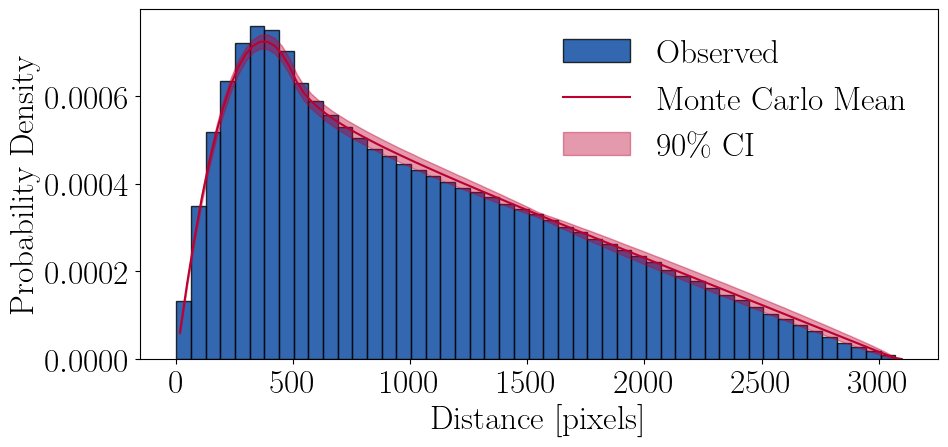

In [61]:
#analyze spatial distribution here
# 90% confidence interval
plt.figure(figsize=(10,5))
ax = plt.gca()
mccolor = '#be0031'
observed_color = '#00429d'
# plt.plot(mc_bin_centers, spline(mc_bin_centers), label='Spline Fit', color='black', linestyle='--')

from scipy.spatial.distance import pdist
bins_ = np.linspace(0,3072,50)

# all_hists = np.zeros(len(bins_)-1)
all_hists = (
        hist.Hist.new.Reg(50, 0, 3072, name="Distances", label="Distances")
        .Weight()
    )
all_distances = []
for q in [0,1,2,3]:
    quad_dipoles = np.array(full_dipole_coord_list[q])
    distances = pdist(quad_dipoles)
    h_from_data = (
        hist.Hist.new.Reg(50, 0, 3072, name="Distances", label="Distances")
        .Weight()
    )
    h_from_data.fill(distances)
    all_distances.append(distances)

    # hist,bins = np.histogram(distances,bins=bins_,density=False)
    # pdf,bins = np.histogram(distances,bins=bins_,density=True)
    all_hists += h_from_data
    # plt.stairs(pdf,bins,label=f'Quadrant {q+1}')


all_distances = np.concatenate(all_distances)
# bin_widths = np.diff(bins)
# pdf = all_hists / (np.sum(all_hists) * bin_widths)


# h = (
#     hist.Hist.new.Reg(len(counts), bin_edges[0], bin_edges[-1], name="x", label="Value")
#     .Double() # Use Double precision for counts
# )

# mchist,bins = np.histogram(mc_distances,bins=bins)
# mchist = mchist/np.sum(mchist)
# plt.stairs(pdf,bins,label='Observed',lw=3)

# all_hists.plot1d(ax=ax,histtype='fill',density=True,yerr=True,label='Observed',alpha=0.8,color=observed_color)
plt.hist(all_distances,bins_,color=observed_color, edgecolor='black', alpha=0.8,label='Observed',density=True)
plt.plot(mc_bin_centers, mc_mean, label='Monte Carlo Mean', color=mccolor)
plt.fill_between(mc_bin_centers, ci_lower, ci_upper, color=mccolor, alpha=0.4, label='90\% CI')
plt.legend(fontsize=small,frameon=False)
# print(np.max(distances))
# plt.hist(distances)
plt.xlabel('Distance [pixels]',fontsize=small)
plt.ylabel('Probability Density',fontsize=small)
# plt.title('Distribution of Dipoles',fontsize=20)
plt.savefig('figures/trap_distribution.pdf',dpi=300)
plt.show()
plt.close()

In [7]:
try:
    dipole_spectra = load_spectra_hdf5('dipole_spectra.h5')
    print("Loaded dipole_spectra.h5")
except FileNotFoundError:
    print("dipole_spectra.h5 not found. Computing...")

Loaded dipole_spectra.h5


In [8]:

useIntensityErr = True
wellBehavedThreshold = 4
threshold_str = f'_{wellBehavedThreshold}'
intensity_str = '_err' if useIntensityErr else ''



threshold_str = f'_{wellBehavedThreshold}'
spectra_filename = f'fit_dipole_spectra{intensity_str}{threshold_str}.h5'

try:
    fit_dipole_spectra = load_spectra_hdf5(spectra_filename)

    print(f"Loaded {spectra_filename}")
except FileNotFoundError:
    print(f"{spectra_filename} not found. Computing...")


Loaded fit_dipole_spectra_err_4.h5


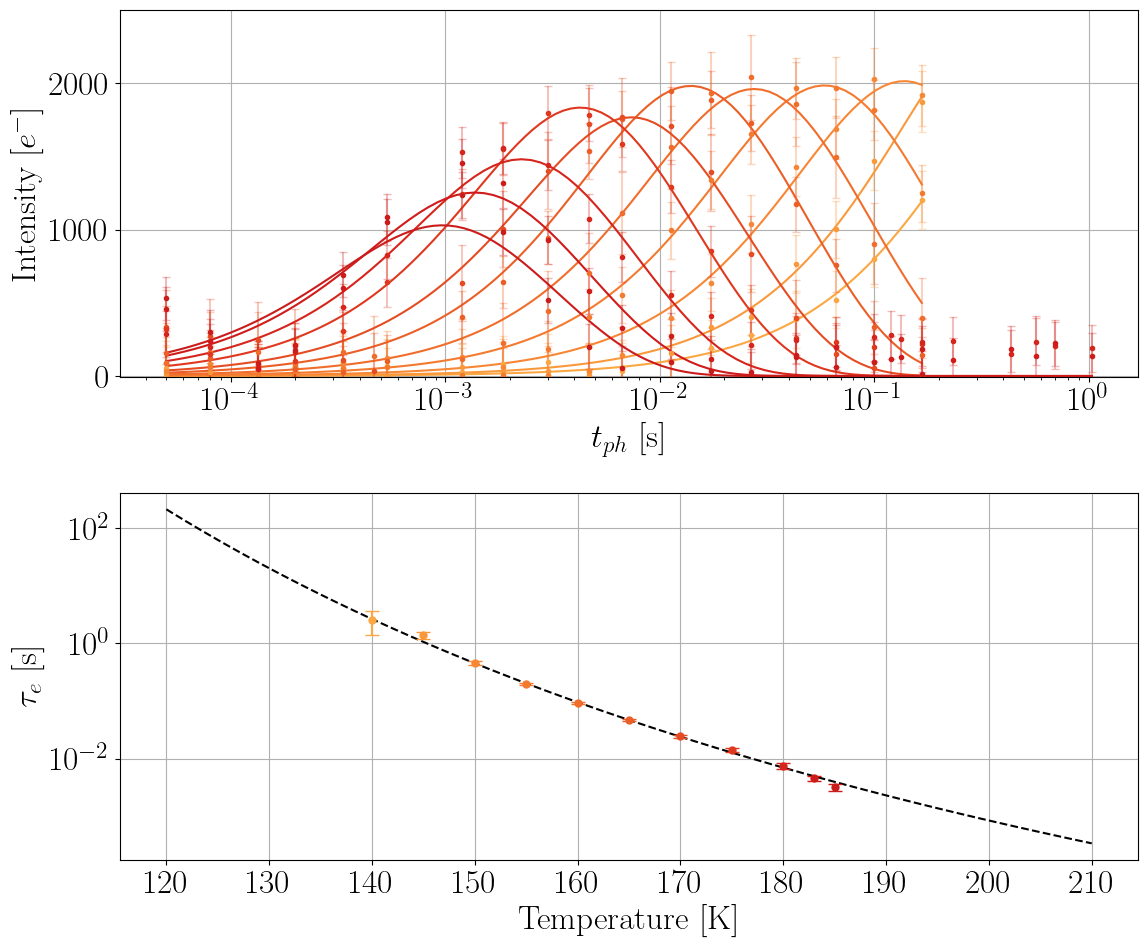

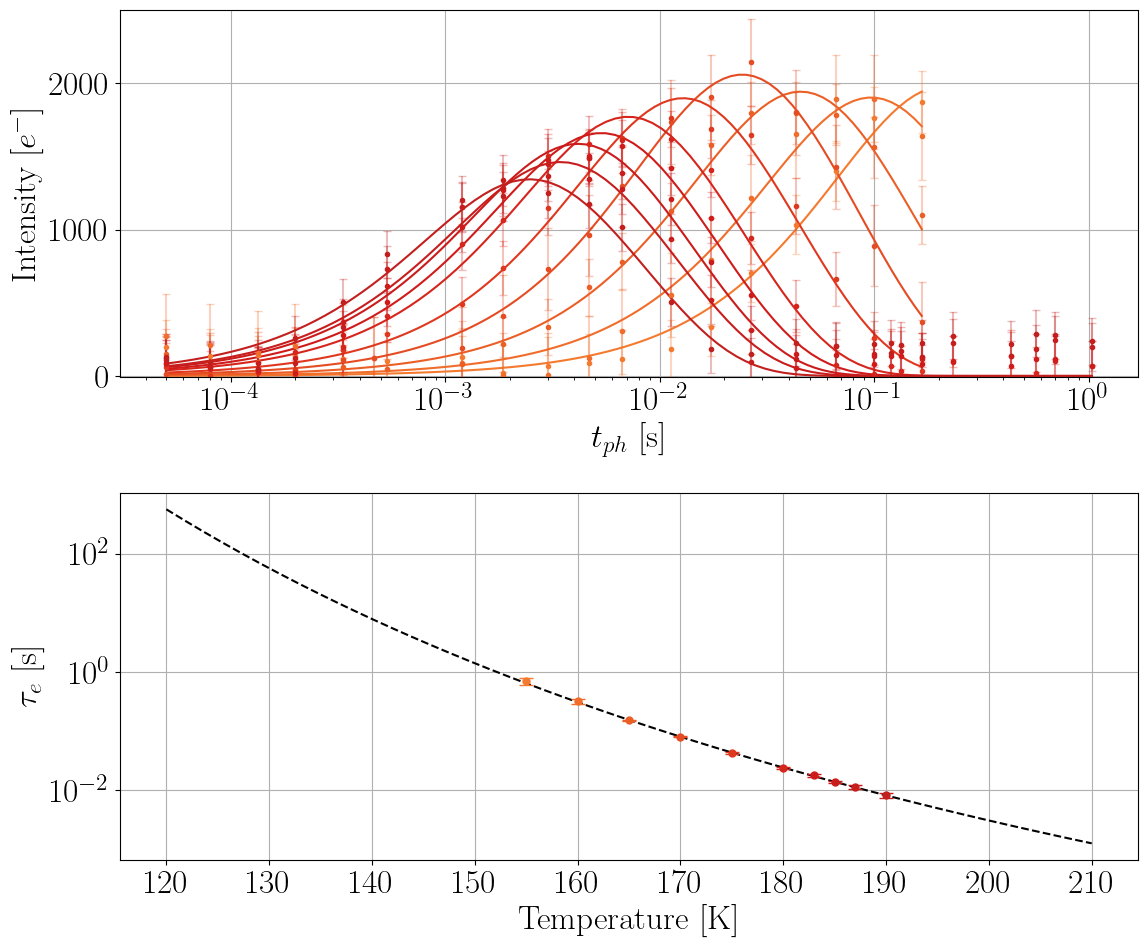

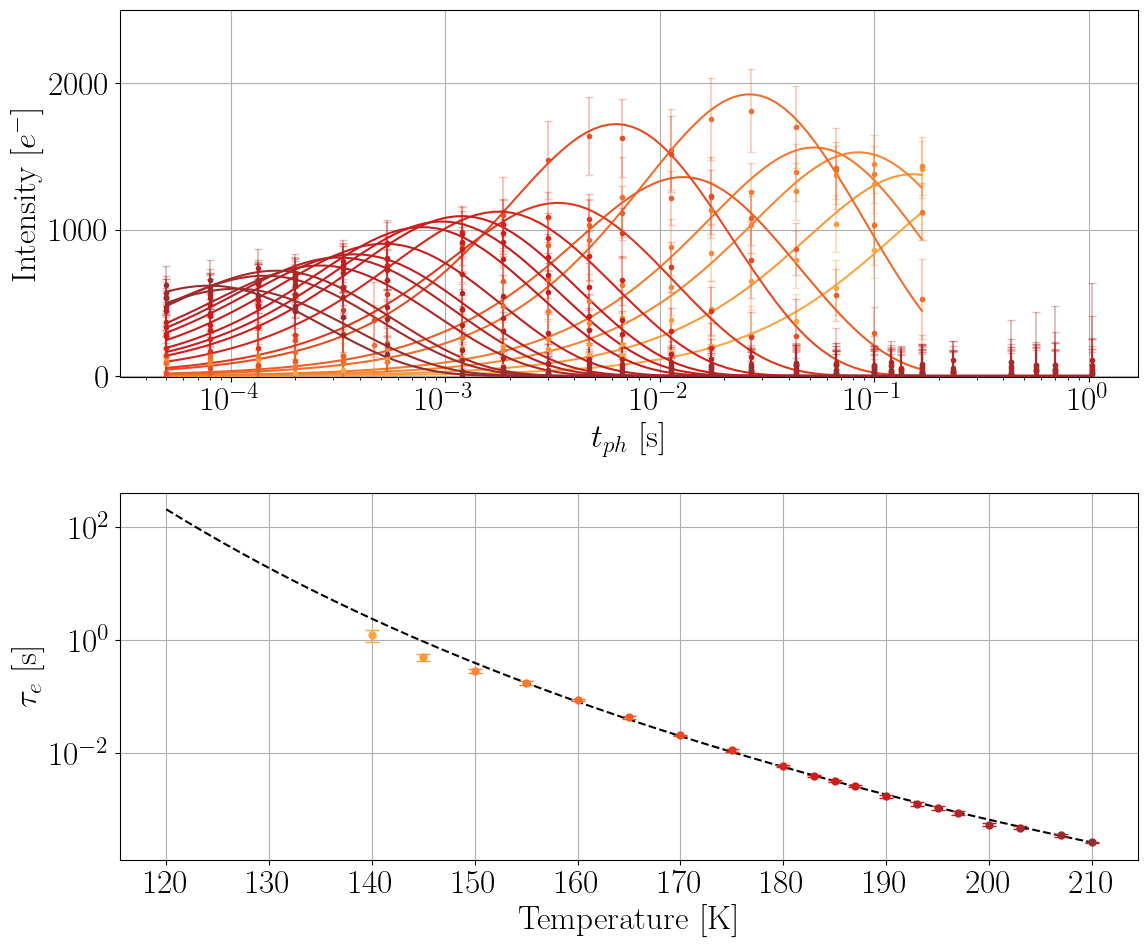

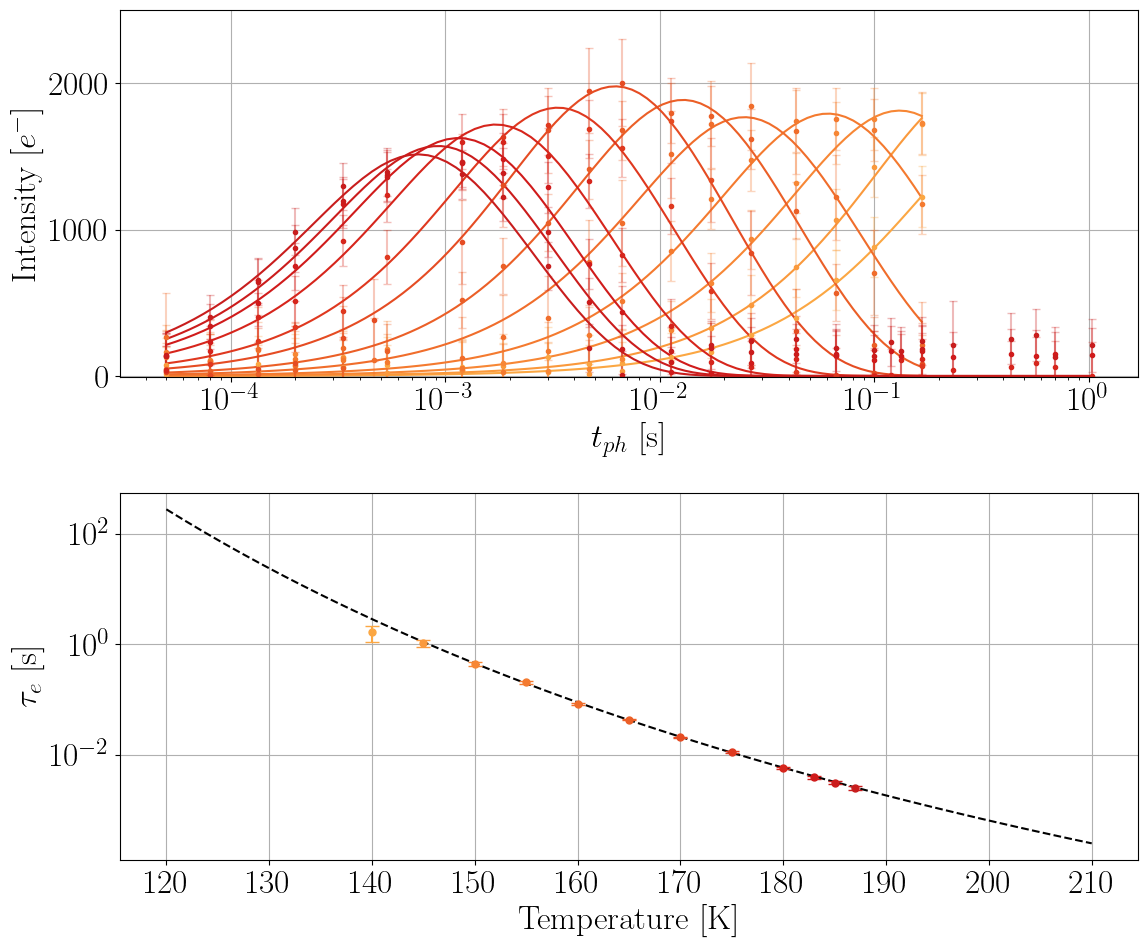

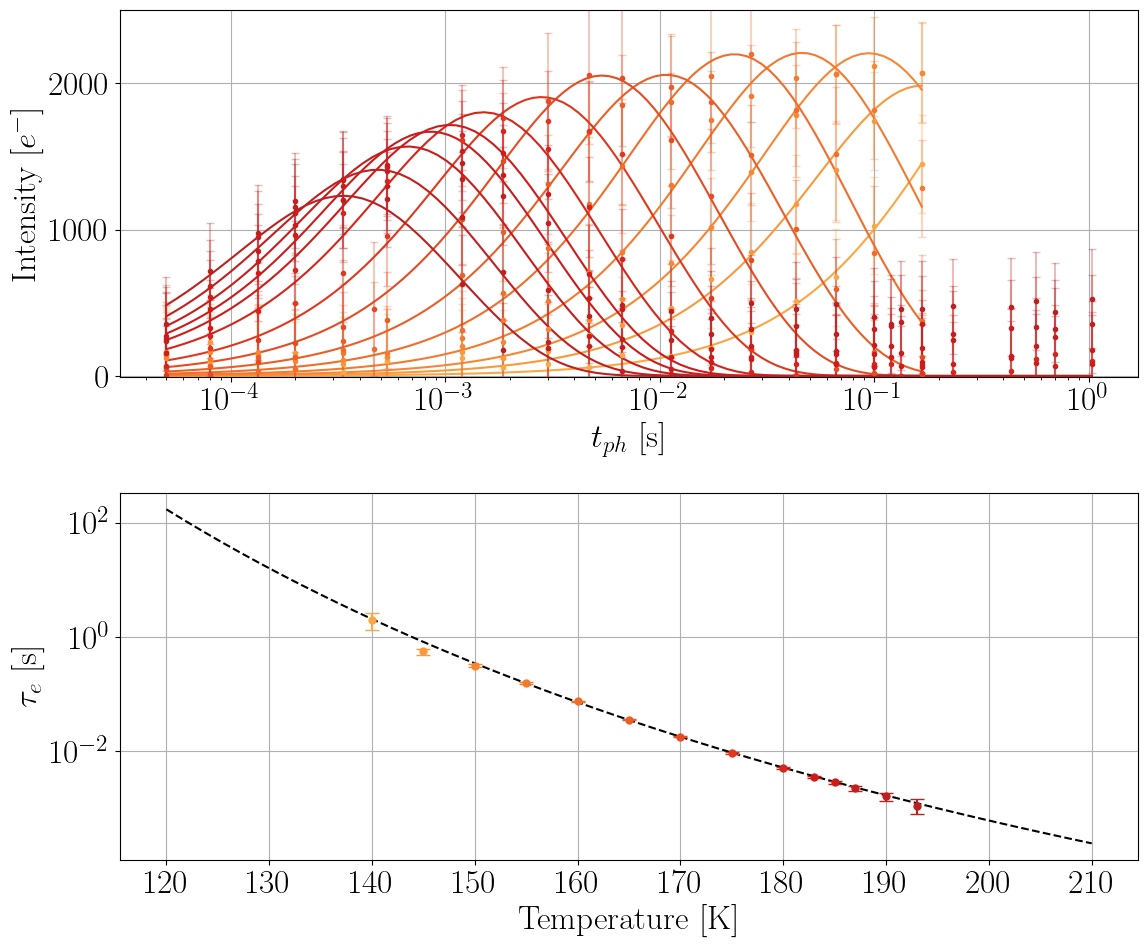

Number of Good Energy Fits Plotted: 
2135


In [62]:
cmap = my_cmap
# cmap = plt.cm.managua_r

norm = colors.Normalize(vmin=100,vmax=250)

energy_crossSections  = []
tau_temp_fits = []
maxtaus = []
plot = True
max_plots = 5
num_plotted = 0
measurement_temperatures = [125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 183, 185, 187, 190, 193, 195, 197, 200, 203, 207, 210]

tau_temperatures = {

}
for t in measurement_temperatures:
    tau_temperatures[t] = {'measured' : [], 'extrapolated': []}
    
# measured_taus = []
# extrapolated_taus = []
for q in [0,1,2,3]:
    
    dpkeys = list(fit_dipole_spectra[q])
    for i in range(len(dpkeys)):
        

        dp = dpkeys[i]
        if type(dp) != tuple:
            continue
        testdp = fit_dipole_spectra[q][dp]
        if testdp['WellBehavedTrap'] and not testdp['EnergyFitFailed']:
            testdpfit = testdp['EnergyFitInfo']

            p_value = testdpfit['p_value'] 
            chi_squared = testdpfit['chi2']
            r2 = testdpfit['r_squared']


            fit_is_good = chi_squared < 100

            fit_is_good = p_value < 0.05
            fit_is_good = testdp["GoodEnergyFit"]
            # fit_is_good = fit_is_good and 
            maxtau = np.max(testdpfit['taus'])
            maxtaus.append(maxtau)
            # fit_is_good = fit_is_good
            # fit_is_good = True


            if fit_is_good:
                cs = testdpfit['BestFitCrossSection']
                cserr = testdpfit['BestFitCrossSectionErr']
                e = testdpfit['BestFitEnergy']
                e_err = testdpfit['BestFitEnergyErr']

                avg_good_temp = np.mean(testdpfit['temperatures'])

                

                

                # if 135 > np.min(testdpfit['temperatures']) and 135 < np.max(testdpfit['temperatures']):
                for t in measurement_temperatures:
                    logtau = log_energy_cross_section(t,e,np.log(cs))
                    tau = np.exp(logtau)
                    
                    if t in testdpfit['temperatures']:
                        tau_temperatures[t]['measured'].append(tau)
                    else:
                        tau_temperatures[t]['extrapolated'].append(tau)



                # if 135 in testdpfit['temperatures']:
                #     measured_taus.append(tau_at_135)
                # else:
                #     extrapolated_taus.append(tau_at_135)
                
                #uncheck this to filter

                # if 135 not in testdp.keys():
                #     continue

                pcov = testdpfit['CovarianceMatrix']
                perr1 = cserr / cs
                perr = np.array([testdpfit['BestFitEnergyErr'],perr1])
                corr_matrix = pcov / np.outer(perr, perr)
                avg_corr = (corr_matrix[0,1] + corr_matrix[1,0])/2
                # if testdp["GoodEnergyFit"]:
                energy_crossSections.append((cs,e,cserr,e_err,avg_good_temp))
                tau_temp_fits.append([testdpfit['temperatures'],testdpfit['taus'],testdpfit['tau_errs']])
                
        
                    
                    
                if plot and num_plotted < max_plots and len(testdpfit['taus']) > 8:
                    num_plotted +=1
                    fig, ax = plt.subplots(2,1,figsize=(12,10))
                    # fig.suptitle(f"Dipole at {int(dp[0]),int(dp[1])} Quad {q+1}",fontsize=large,y=0.94)
                    ax[0].set_xlabel('$t_{ph}$ [s]',fontsize=small)
                    ax[0].set_ylabel('Intensity [$e^-$]',fontsize=small)

                    ax[1].set_xlabel('Temperature [K]',fontsize=small)
                    ax[1].set_ylabel('$\\tau_e$ [s]',fontsize=small)
                    ax[1].set_xticks([120,130,140,150,160,170,180,190,200,210])
                    ax[0].set_xscale('log')
                    ax[1].set_yscale('log')

                    ax[0].set_ylim(-10,2500)

                    for temp in testdp.keys():
                        if type(temp) != int:
                            continue

                        color = cmap(norm(temp))
                        dipole = testdp[temp]
                        if dipole['GoodIntensityFit']:
                            sigma_image = dipole['image_sigma']
                            
                            # ax[0].scatter(dipole['seconds'],dipole['intensities'],color=color)

                            yerr = dipole['intensity_err'] if useIntensityErr else dipole['poisson_err']

                            # if useIntensityErr:
                            # line, caps, bars = ax[1].errorbar(data[0],data[1],yerr=data[3],ls='None',color=color,capsize=3,marker='o',markersize=4)
                            line, caps, bars = ax[0].errorbar(dipole['seconds'],dipole['intensities'],yerr=yerr,color=color,ls='None',capsize=3,marker='o',markersize=3)
                            for cap in caps:
                                cap.set_alpha(0.3)
                            for bar in bars:
                                bar.set_alpha(0.3)
                            # else:
                                # ax[0].errorbar(dipole['seconds'],dipole['intensities'],yerr=dipole['poisson_err'],color=color,ls='None')

                            seconds = np.geomspace(np.min(dipole['seconds']),np.max(dipole['seconds']),100)
                            fit_ints = intensity_function(seconds,dipole['IntensityFitInfo']['fit_coeff'],dipole['IntensityFitInfo']['fit_tau'])
                            ax[0].plot(seconds,fit_ints,ls='-',color=cmap(norm(temp)))
                            

                    
                    
                    


                    



                    temperatures = np.linspace(120,210,50)
                    log_fit_taus = log_energy_cross_section(temperatures,testdpfit['BestFitEnergy'],np.log(testdpfit['BestFitCrossSection']))
                    fit_taus = np.exp(log_fit_taus)
                    ax[1].plot(temperatures,fit_taus,color='black',ls='--')
                    for t in range(len(testdpfit['temperatures'])):
                        temp = testdpfit['temperatures'][t]
                        color = cmap(norm(temp))
                        tau = testdpfit['taus'][t]
        
                        # ax[1].scatter(temp,tau,color=color)
                        tau_err = testdpfit['tau_errs'][t]

                        ax[1].errorbar(temp,tau,yerr=tau_err,ls='None',color=color,marker='o',markersize=5,capsize=5)
                    # import matplotlib.cm as cmx
                    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
                    # sm.set_array([])  # Required for ScalarMappable to work correctly
                    # cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
                    # cbar = fig.colorbar(sm, cax=cbar_ax)
                    
                    # cbar.set_label('Temperature [K]',fontsize=12)
                    # plt.tight_layout()
                    ax[0].grid()
                    ax[1].grid()
                    plt.savefig(f'figures/example_trap_{num_plotted-1}.pdf',dpi=300)

                    plt.show()
                    plt.close()
                










print("Number of Good Energy Fits Plotted: ")
print(len(energy_crossSections))


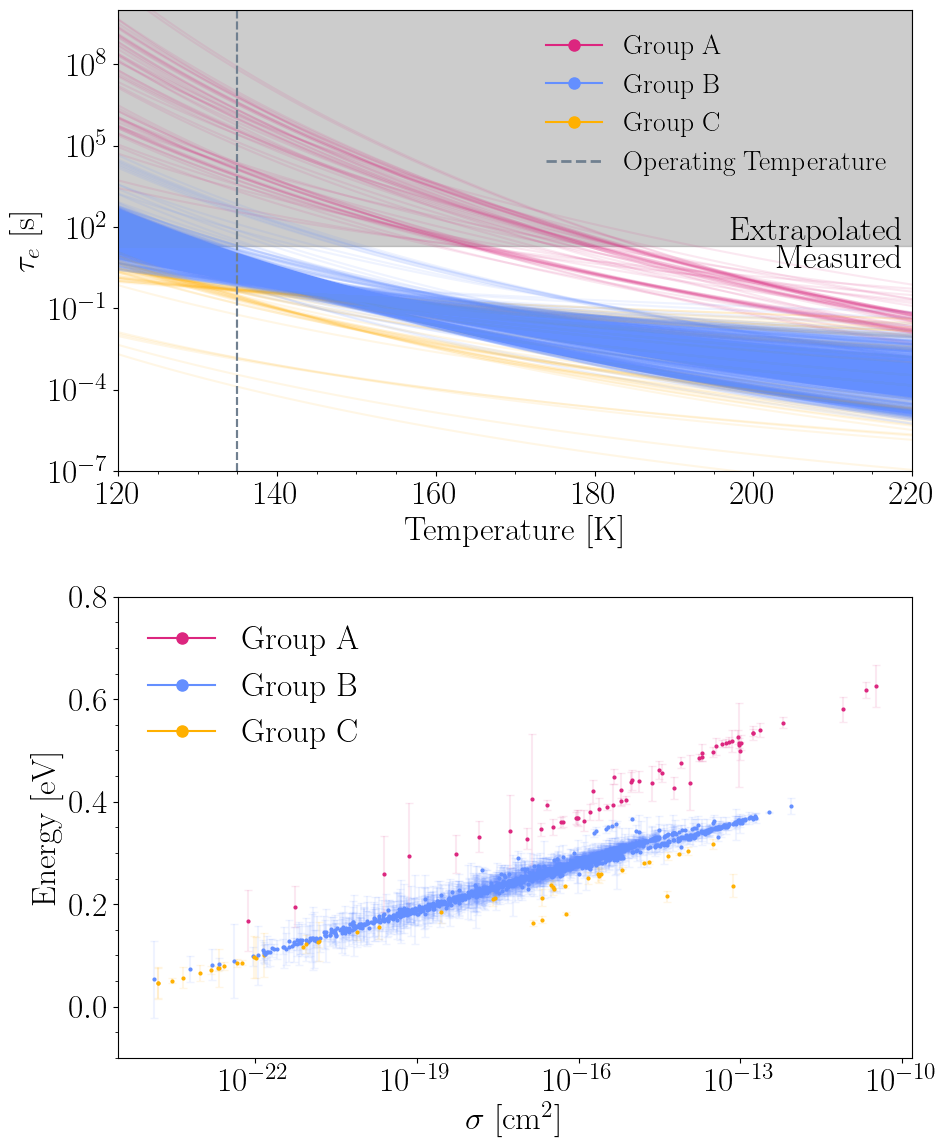

In [65]:
max_tau = 0
for t in range(len(tau_temp_fits)):
    tau = tau_temp_fits[t][1]
    if max_tau < np.max(tau):
        max_tau = np.max(tau)


fig, ax= plt.subplots(2,figsize=(10,12))
fit_temp = np.linspace(120,220,100)

cmap = plt.cm.plasma
cross_sections = np.array(energy_crossSections)[:,0]
log_cross_sections = np.log(cross_sections)


#decision_boundary
# m = 0.014  
# b = 0.85 
T = 170 #histogram
kb = 8.6717333262e-5
m =  (kb*T)
tau_test = 1
# tau_test = 0.00002
# np.log(0.00002)
b = m * (np.log(tau_test) - (-68.267 ) + 2 * np.log(m))


T2 = 130
m2 =  (kb*T2)
b2 = m2 * (np.log(tau_test) - (-68.267 ) + 2 * np.log(m2))

# plt.plot(x_vals, m * x_vals + b, linestyle='--', label=f'{T}K')




avg_A = []
avg_B = []
avg_C = []

# print(len(energies),len(energy_crossSections))
norm = colors.LogNorm(vmin=np.min(cross_sections),vmax=np.max(cross_sections))
for d,data in enumerate(energy_crossSections):
    temperatures = tau_temp_fits[d][0]
    taus = tau_temp_fits[d][1]
    tau_errs = tau_temp_fits[d][2]
    energy = data[1]
    cs = data[0]
    avgtemp = data[4]
    if energy > (m * np.log(cs) + b):
        color ='#DC267F'
        # color ='c'
        avg_A.append(avgtemp)
    elif energy < (m2 * np.log(cs) + b2):
        color = '#FFB000'
        # color = 'm'
        avg_C.append(avgtemp)
    else:
        color = '#648FFF'

        # color = 'y'
        avg_B.append(avgtemp)


    # color = cmap(d)
    # color = cmap(norm(cs))

    log_tau_fit = log_energy_cross_section(fit_temp,data[1],np.log(data[0]))
    tau_fit = np.exp(log_tau_fit)
    ax[0].plot(fit_temp,tau_fit,color=color,alpha=0.1)
    # ax[0].scatter(temperatures,taus,color=color,s=9)
    # ax[0].errorbar(temperatures,taus,yerr=tau_errs,color=color,ls="None",capsize=1)
    # ax[1].scatter(data[0],data[1],color=color,s=9)
    # ax[1].errorbar(data[0],data[1],xerr=data[2],yerr=data[3],ls='None',color='slategrey',alpha=0.1,capsize=3)
 
    
    line, caps, bars = ax[1].errorbar(data[0],data[1],yerr=data[3],ls='None',color=color,capsize=3,marker='o',markersize=2)
    for bar in bars:
        bar.set_alpha(0.1)

    for cap in caps:
        cap.set_alpha(0.1)


ax[0].text(219,3.16e1,"Extrapolated",fontsize=small,ha='right')
ax[0].text(219,3.16,"Measured",fontsize=small,ha='right')

ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[0].fill_between(fit_temp,np.ones_like(fit_temp)*max_tau,np.ones_like(fit_temp)*1e10,color='grey',alpha=0.4)
ax[0].set_ylim(1e-7,1e10)
ax[0].set_xlim(120,220)

ax[0].set_xlabel("Temperature [K]",fontsize=small)
ax[0].set_ylabel("$\\tau_e$ [s]",fontsize=small)

ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)
ax[1].set_ylabel("Energy [eV]",fontsize=small)
ax[1].set_ylim(-0.1,0.8)
ax[0].axvline(135,ls='--',label='Operating Temperature',color='slategrey')

ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)
ax[1].set_ylabel("Energy [eV]",fontsize=small)
ax[1].set_ylim(-0.1,0.8)
ax[0].axvline(135,ls='--',label='Operating Temperature',color='slategrey')
ax[0].minorticks_on()
ax[1].minorticks_on()

# --- Add this block to create and display custom legend handles ---
custom_handles = [
    Line2D([0], [0], marker='o', color='#DC267F', markerfacecolor='#DC267F', markersize=8, label='Group A'),
    Line2D([0], [0], marker='o', color='#648FFF', markerfacecolor='#648FFF', markersize=8, label='Group B'),
    Line2D([0], [0], marker='o', color='#FFB000', markerfacecolor='#FFB000', markersize=8, label='Group C'),
    Line2D([0], [0], linestyle='--', color='slategrey', lw=2, label='Operating Temperature')

]

custom_handles2 = [
    Line2D([0], [0], marker='o', color='#DC267F', markerfacecolor='#DC267F', markersize=8, label='Group A'),
    Line2D([0], [0], marker='o', color='#648FFF', markerfacecolor='#648FFF', markersize=8, label='Group B'),
    Line2D([0], [0], marker='o', color='#FFB000', markerfacecolor='#FFB000', markersize=8, label='Group C'),

]
# custom_handles = custom_handles +  obs_handle
# Add the legend to the bottom plot (ax[1])
ax[0].legend(handles=custom_handles, loc='best', fontsize=smaller,frameon=False)
ax[1].legend(handles=custom_handles2, loc='best', fontsize=small,frameon=False)
# --

# fig.suptitle("Characterized Charge Traps",fontsize=24,y=0.92)
# plt.tight_layout()
# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])  # Required for ScalarMappable to work correctly
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
# cbar = fig.colorbar(sm, cax=cbar_ax)
# cbar.set_label('$\sigma$ [cm$^2$]',fontsize=16)
plt.savefig('figures/characterized_traps.pdf',dpi=300)

plt.show()
plt.close()

242
1893


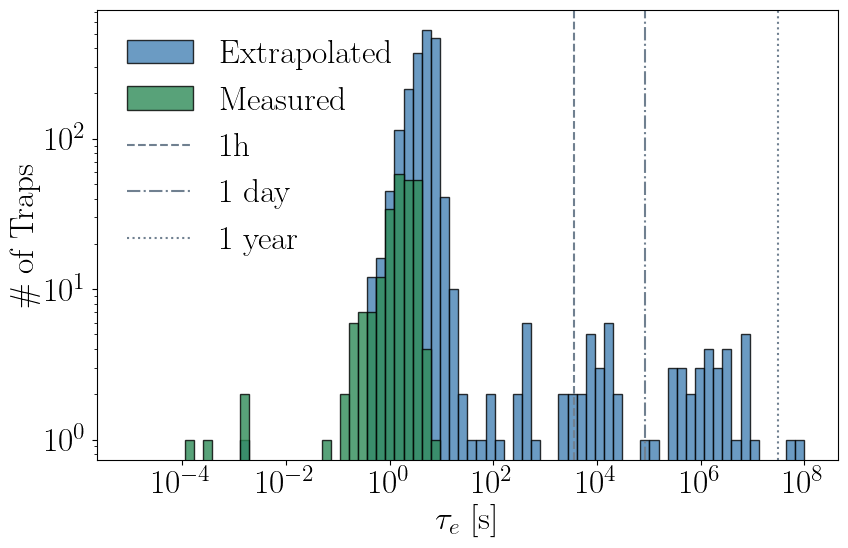

In [78]:
import hist
from hist import Hist
# fig,ax = plt.subplots(1,2,figsize=(14,6))

# for t in tau_temperatures.keys():
t = 135
fig = plt.figure(figsize=(9,6))
ax = plt.gca()
measured_taus = tau_temperatures[t]['measured']
extrapolated_taus = tau_temperatures[t]['extrapolated']

print(len(measured_taus))
print(len(extrapolated_taus))
minbin = np.min([np.min(measured_taus),np.min(extrapolated_taus)])
maxbin = np.max([np.max(measured_taus),np.max(extrapolated_taus)])

bins = np.geomspace(1e-5,1e8,75)

# mhist= Hist.new.Log(200, minbin, maxbin, name="Measured Emission Times").Weight()
# ehist= Hist.new.Log(200, minbin, maxbin, name="Extrapolated Emission Times").Weight()

# mhist.fill(measured_taus)
# ehist.fill(extrapolated_taus)

# mhist,mbins = np.histogram(measured_taus,bins=bins)
# ehist,ebins = np.histogram(extrapolated_taus,bins=bins)

# plt.stairs(mhist,mbins,color='blue',label='measured',lw=2)
# plt.stairs(ehist,ebins,color='grey',label='extrapolated',lw=2)
# mhist.plot1d(ax=ax[0],histtype='fill',yerr=False)
# ehist.plot1d(ax=ax[1],histtype='fill',yerr=False)


# ax.hist(measured_taus+extrapolated_taus, bins, color='slategrey', edgecolor='black', alpha=1,label='Total')
ax.hist(extrapolated_taus, bins, color='steelblue', edgecolor='black', alpha=0.8,label='Extrapolated')
ax.hist(measured_taus, bins, color='seagreen', edgecolor='black', alpha=0.8,label='Measured')


# ax.legend(fontsize=16)
# ax.set_title(f"Emission $\\tau_e$ of CCD Traps at {t}k",fontsize=20)
# ax[1].set_title("Extrapolated Emission $\\tau_e$ of CCD Traps at 135k",fontsize=20)
# for a in ax:
ax.set_xlabel('$\\tau_e$ [s]',fontsize=small)
ax.set_ylabel("\# of Traps",fontsize=small)
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_ylim(0,500)
# ax[0].set_ylim(0,50)
plt.axvline(3600,label='1h',ls='--',color='slategrey')
plt.axvline(3600*24,label='1 day',ls='-.',color='slategrey')
plt.axvline(3600*24*365,label='1 year',ls=':',color='slategrey')
ax.legend(frameon=False,loc='upper left')
ax.minorticks_on()
plt.savefig(f'figures/tau_at_{t}k_hist.pdf',dpi=300)
plt.show()
plt.close()

In [66]:


for t in tau_temperatures.keys():
    measured_taus = tau_temperatures[t]['measured']
    extrapolated_taus = tau_temperatures[t]['extrapolated']
    
    # The 'Truth' or total number of traps is the sum of both lists
    total_taus = measured_taus + extrapolated_taus
    
    if len(total_taus) == 0:
        continue
        
    print(f"Temperature: {t}K | Measured: {len(measured_taus)} | Extrapolated: {len(extrapolated_taus)}")

    # Set up a 2-panel plot (Top for Histogram, Bottom for Efficiency)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ax_hist = axes[0]
    ax_eff = axes[1]
    
    bins = np.geomspace(1e-7, 1e8, 50)

    # 1. Plot the Standard Histograms (Top Panel)
    # Using stacked=True is often better here so "Measured" sits on top of "Extrapolated" to show the Total
    ax_hist.hist([measured_taus, extrapolated_taus], bins=bins, stacked=True, 
                 color=['seagreen', 'steelblue'], edgecolor='black', alpha=0.8, 
                 label=['Measured', 'Extrapolated'])

    ax_hist.set_title(f"Emission $\\tau_e$ of CCD Traps at {t}K", fontsize=20)
    ax_hist.set_ylabel("\# of Traps", fontsize=16)
    
    ax_hist.axvline(3600, label='1h', ls='--', color='slategrey')
    ax_hist.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
    ax_hist.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')
    ax_hist.legend(frameon=False, fontsize=16)

    # 2. Calculate the Efficiency (Bottom Panel)
    # Bin the data manually to do the math
    meas_counts, _ = np.histogram(measured_taus, bins=bins)
    extrap_counts, _ = np.histogram(extrapolated_taus, bins=bins)
    tot_counts, _ = np.histogram(total_taus, bins=bins)
    
    # Avoid division by zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency = meas_counts / tot_counts
        
    # Find the geometric centers of the bins for plotting the scatter points
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # Calculate simple binomial errors for the efficiency
    eff_err = np.zeros_like(efficiency)
    valid = tot_counts > 0
    eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    # Plot the efficiency points with error bars
    ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
                    fmt='o', color='black', markersize=5, capsize=3)
    
    # Formatting the Efficiency Panel
    ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=small)
    ax_eff.set_ylabel("Efficiency $\\epsilon$", fontsize=small)
    ax_eff.set_xscale('log')
    ax_eff.set_ylim(-0.1, 1.1)
    ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    ax_eff.grid(True, which='both', axis='x', alpha=0.2)

    ax_eff.set_xticks(np.logspace(-8,8,17))
    ax_eff.minorticks_on()

    ax_eff.axvline(1e0,ls='--',color='slategrey')
    
    plt.tight_layout()
    # if t == 135:
        # plt.savefig('figures/tau_at_135k_hist.pdf',dpi=300)
    # plt.show()
    plt.close()

    # 3. Save the data individually for this specific temperature
    filename = f'tau_at_{t}k_hist.npz'
    np.savez(filename, 
             hist=tot_counts,           # Loaded as 'tau_weights' in run_ccd_simulation.py
             bin_edges=bins,            # Loaded as 'tau_edges' in run_ccd_simulation.py
             measured_taus=measured_taus,
             extrapolated_taus=extrapolated_taus,
             total_taus=total_taus,
             meas_counts=meas_counts,
             extrap_counts=extrap_counts,
             efficiency=efficiency,
             eff_err=eff_err)
    
    print(f"Saved {filename} for simulation sampling.")


Temperature: 125K | Measured: 20 | Extrapolated: 2115
Saved tau_at_125k_hist.npz for simulation sampling.
Temperature: 130K | Measured: 33 | Extrapolated: 2102
Saved tau_at_130k_hist.npz for simulation sampling.
Temperature: 135K | Measured: 242 | Extrapolated: 1893
Saved tau_at_135k_hist.npz for simulation sampling.
Temperature: 140K | Measured: 1177 | Extrapolated: 958
Saved tau_at_140k_hist.npz for simulation sampling.
Temperature: 145K | Measured: 1924 | Extrapolated: 211
Saved tau_at_145k_hist.npz for simulation sampling.
Temperature: 150K | Measured: 2026 | Extrapolated: 109
Saved tau_at_150k_hist.npz for simulation sampling.
Temperature: 155K | Measured: 1987 | Extrapolated: 148
Saved tau_at_155k_hist.npz for simulation sampling.
Temperature: 160K | Measured: 1695 | Extrapolated: 440
Saved tau_at_160k_hist.npz for simulation sampling.
Temperature: 165K | Measured: 1136 | Extrapolated: 999
Saved tau_at_165k_hist.npz for simulation sampling.
Temperature: 170K | Measured: 739 | Ext

Total Traps Measured: 15233
Total Traps Extrapolated: 33872


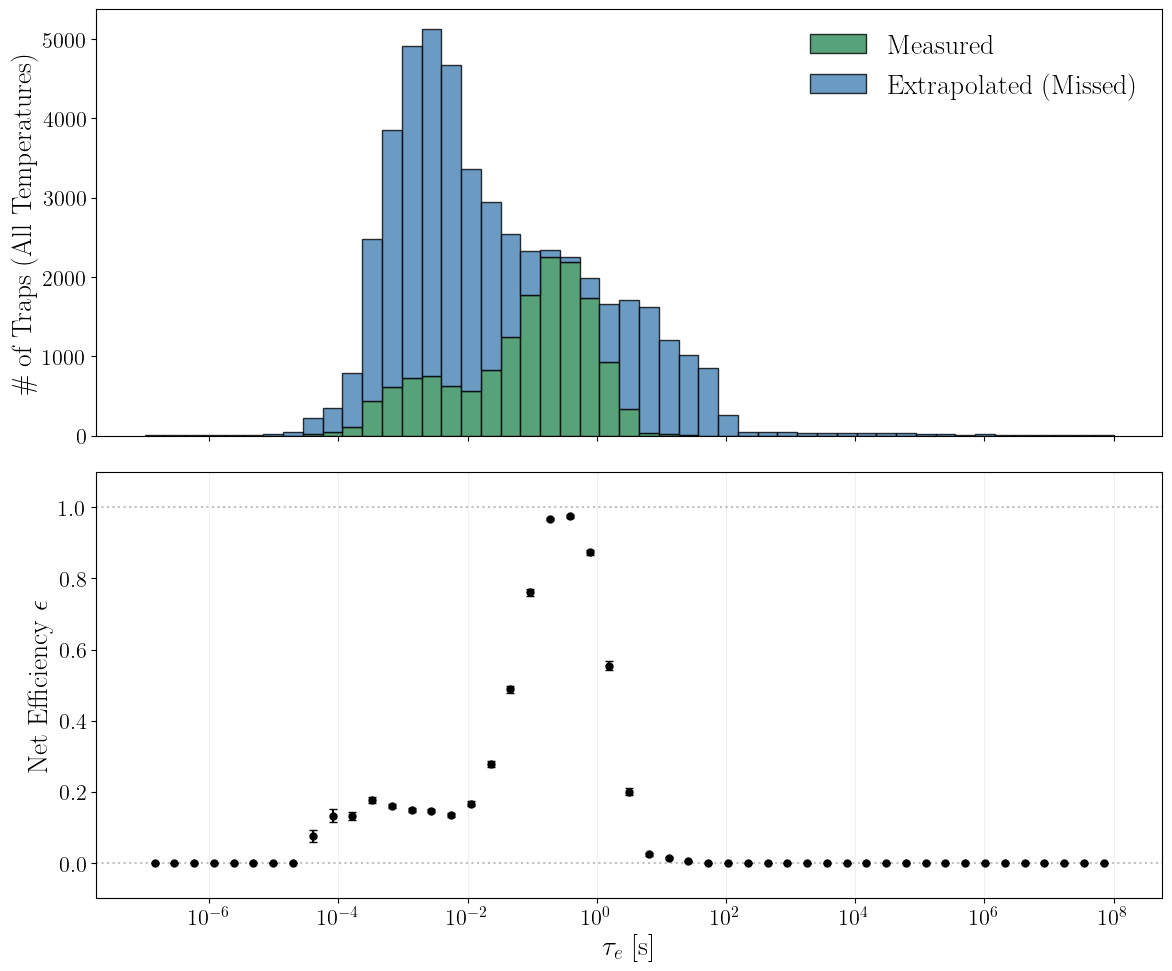

In [40]:


# 1. Aggregate data across all temperatures
all_measured_taus = []
all_extrapolated_taus = []

for t in tau_temperatures.keys():
    all_measured_taus.extend(tau_temperatures[t]['measured'])
    all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

all_total_taus = all_measured_taus + all_extrapolated_taus

print(f"Total Traps Measured: {len(all_measured_taus)}")
print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

if len(all_total_taus) > 0:
    # 2. Set up the Two-Panel Plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
    ax_hist = axes[0]
    ax_eff = axes[1]
    
    # bins = np.geomspace(1e-7, 1e8, 75)

    # --- Top Panel: Stacked Histogram ---
    ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
                 color=['seagreen', 'steelblue'], edgecolor='black', alpha=0.8, 
                 label=['Measured', 'Extrapolated (Missed)'])

    # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
    ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
    # ax_hist.set_yscale('log')
    
    # ax_hist.axvline(3600, label='1h', ls='--', color='slategrey')
    # ax_hist.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
    # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')
    ax_hist.legend(frameon=False, fontsize=medium)

    # --- Bottom Panel: Net Efficiency ---
    meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
    tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
    # Safely calculate efficiency
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency = meas_counts / tot_counts
        
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # Calculate binomial errors
    eff_err = np.zeros_like(efficiency)
    valid = tot_counts > 0
    eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
                    fmt='o', color='black', markersize=5, capsize=3)
    
    # Formatting
    ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=medium)
    ax_eff.set_ylabel("Net Efficiency $\\epsilon$", fontsize=medium)
    ax_eff.set_xscale('log')
    ax_eff.set_ylim(-0.1, 1.1)
    ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    ax_eff.grid(True, which='both', axis='x', alpha=0.2)

    plt.tight_layout()
    
    plt.show()
    plt.close()
else:
    print("No data available to plot.")


Total Traps Measured: 15233
Total Traps Extrapolated: 33872


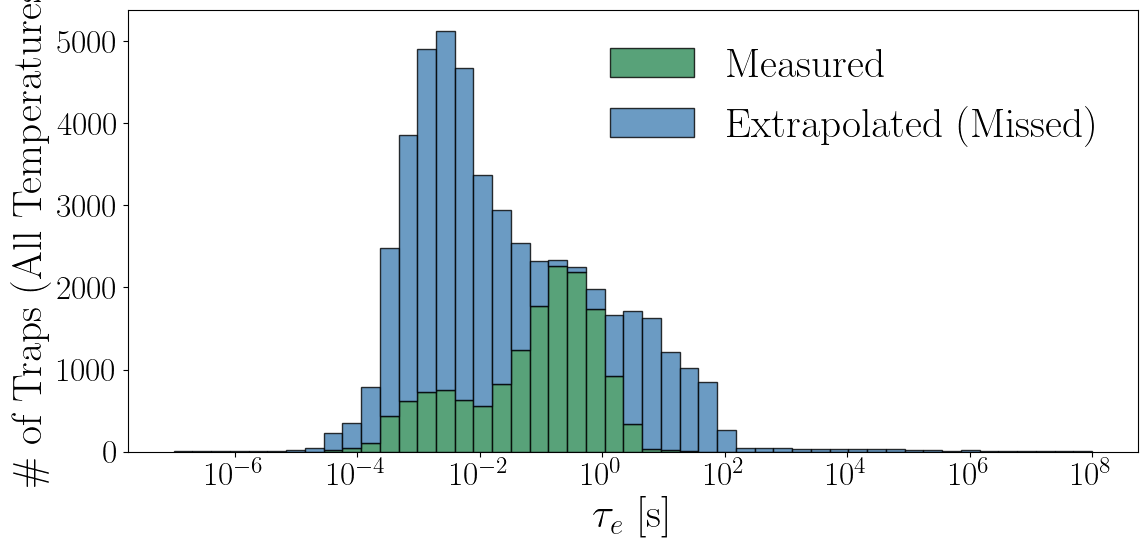

In [84]:


# 1. Aggregate data across all temperatures
all_measured_taus = []
all_extrapolated_taus = []

for t in tau_temperatures.keys():
    all_measured_taus.extend(tau_temperatures[t]['measured'])
    all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

all_total_taus = all_measured_taus + all_extrapolated_taus

print(f"Total Traps Measured: {len(all_measured_taus)}")
print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

if len(all_total_taus) > 0:
    # 2. Set up the Two-Panel Plot
    # fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
    fig = plt.figure(figsize=(12,6))
    ax_hist = plt.gca()
    # ax_eff = axes[1]
    
    bins = np.geomspace(1e-7, 1e8, 50)

    # --- Top Panel: Stacked Histogram ---
    ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
                 color=['seagreen', 'steelblue'], edgecolor='black', alpha=0.8, 
                 label=['Measured', 'Extrapolated (Missed)'])

    # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
    ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
    ax_hist.set_xscale('log')
    
    # ax_hist.axvline(3600, label='1h', ls='--', color='slategrey')
    # ax_hist.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
    # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')
    ax_hist.legend(frameon=False, fontsize=medium)

    # --- Bottom Panel: Net Efficiency ---
    # meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
    # tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
    # Safely calculate efficiency
    # with np.errstate(divide='ignore', invalid='ignore'):
        # efficiency = meas_counts / tot_counts
        
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # # Calculate binomial errors
    # eff_err = np.zeros_like(efficiency)
    # valid = tot_counts > 0
    # eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    # ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
    #                 fmt='o', color='black', markersize=5, capsize=3)
    
    # # Formatting
    ax_hist.set_xlabel('$\\tau_e$ [s]', fontsize=medium)
    # ax_eff.set_ylabel("Net Efficiency $\\epsilon$", fontsize=medium)
    # ax_eff.set_xscale('log')
    # ax_eff.set_ylim(-0.1, 1.1)
    # ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    # ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    # ax_eff.grid(True, which='both', axis='x', alpha=0.2)

    plt.tight_layout()
    
    plt.show()
    plt.close()
else:
    print("No data available to plot.")


Total Traps Measured: 15233
Total Traps Extrapolated: 33872


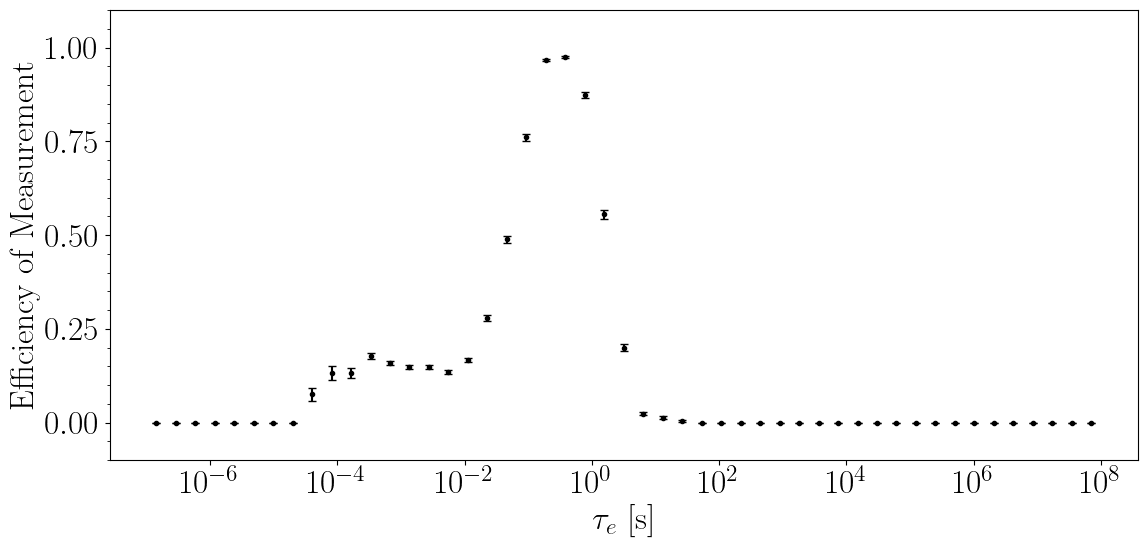

In [85]:

# 1. Aggregate data across all temperatures
all_measured_taus = []
all_extrapolated_taus = []

for t in tau_temperatures.keys():
    all_measured_taus.extend(tau_temperatures[t]['measured'])
    all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

all_total_taus = all_measured_taus + all_extrapolated_taus

print(f"Total Traps Measured: {len(all_measured_taus)}")
print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

if len(all_total_taus) > 0:
    # 2. Set up the Two-Panel Plot
    # fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
    fig = plt.figure(figsize=(12,6))
    # ax_hist = plt.gca()
    ax_eff =  plt.gca()
    
    # bins = np.geomspace(1e-7, 1e8, 75)

    # --- Top Panel: Stacked Histogram ---
    # ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
                #  color=['seagreen', 'steelblue'], edgecolor='black', alpha=0.8, 
                #  label=['Measured', 'Extrapolated (Missed)'])

    # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
    # ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
    ax_eff.set_xscale('log')
    
    # ax_hist.axvline(3600, label='1h', ls='--', color='slategrey')
    # ax_hist.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
    # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')
    # ax_hist.legend(frameon=False, fontsize=medium)

    # --- Bottom Panel: Net Efficiency ---
    meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
    tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
    # Safely calculate efficiency
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency = meas_counts / tot_counts
        
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # Calculate binomial errors
    eff_err = np.zeros_like(efficiency)
    valid = tot_counts > 0
    eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
                    fmt='o', color='black', markersize=3, capsize=3)
    
    # # Formatting
    ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=small)
    ax_eff.set_ylabel("Efficiency of Measurement", fontsize=small)
    ax_eff.set_xscale('log')
    ax_eff.set_ylim(-0.1, 1.1)
    ax_eff.minorticks_on()
    # ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    # ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    # ax_eff.grid(True, which='both', axis='x', alpha=0.2)

    plt.tight_layout()
    
    plt.show()
    plt.close()
else:
    print("No data available to plot.")


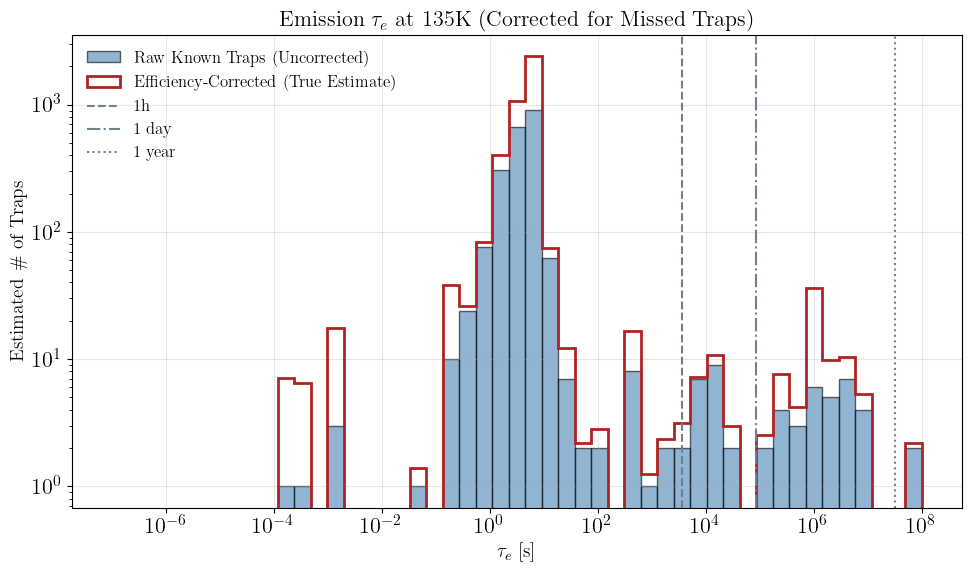

In [14]:

# ====================================================================
# 1. Build the Universal "Master Efficiency Curve"
# ====================================================================
all_measured = []
all_extrapolated = []
for t in tau_temperatures.keys():
    all_measured.extend(tau_temperatures[t]['measured'])
    all_extrapolated.extend(tau_temperatures[t]['extrapolated'])

all_total = all_measured + all_extrapolated
# bins = np.geomspace(1e-7, 1e8, 75)

meas_counts, _ = np.histogram(all_measured, bins=bins)
tot_counts, _ = np.histogram(all_total, bins=bins)

# Calculate efficiency safely
with np.errstate(divide='ignore', invalid='ignore'):
    master_efficiency = meas_counts / tot_counts
    
bin_centers = np.sqrt(bins[:-1] * bins[1:])

# Create a safe trust window (only trust regions with > 5% efficiency)
trust_mask = (master_efficiency > 0.05) & (~np.isnan(master_efficiency))

# Create a continuous interpolation function for the efficiency
# master_eff_func = interp1d(
#     bin_centers[trust_mask], 
#     master_efficiency[trust_mask], 
#     kind='linear', 
#     bounds_error=False, 
#     fill_value=np.nan
# )

master_eff_func = interp1d(
    bin_centers, 
    master_efficiency, 
    kind='linear', 
    bounds_error=False, 
    fill_value=np.nan
)

# ====================================================================
# 2. Weight every characterized trap based on where it was observed
# ====================================================================
target_temp = 135.0

tau_target_list = []
weights_list = []

for d, data in enumerate(energy_crossSections):
    cs = data[0]
    energy = data[1]
    avgtemp = data[4]  # The temperature where this trap was best measured
    
    # Calculate the tau of this trap AT THE TEMPERATURE IT WAS MEASURED
    logtau_obs = log_energy_cross_section(avgtemp, energy, np.log(cs))
    tau_obs = np.exp(logtau_obs)
    
    # Get the efficiency for this tau from our master curve
    trap_eff = master_eff_func(tau_obs)
    
    # Skip traps that fell outside our 5% reliable interpolation window
    if np.isnan(trap_eff) or trap_eff <= 0:
        continue 
        
    trap_weight = 1.0 / trap_eff
    
    # Now, calculate the tau of this trap at our TARGET extrapolated temperature
    logtau_target = log_energy_cross_section(target_temp, energy, np.log(cs))
    tau_target = np.exp(logtau_target)
    
    tau_target_list.append(tau_target)
    weights_list.append(trap_weight)

# ====================================================================
# 3. Plot the final Corrected Histogram!
# ====================================================================
plt.figure(figsize=(10, 6))

# Plot the Unweighted (Raw Known Traps)
plt.hist(tau_target_list, bins=bins, color='steelblue', edgecolor='black', 
         alpha=0.6, label='Raw Known Traps (Uncorrected)')

# Plot the Weighted (True Extrapolated Estimate)
plt.hist(tau_target_list, bins=bins, weights=weights_list, 
         edgecolor='firebrick', lw=2, histtype='step', 
         label='Efficiency-Corrected (True Estimate)')

plt.title(f"Emission $\\tau_e$ at {int(target_temp)}K (Corrected for Missed Traps)", fontsize=16)
plt.xlabel('$\\tau_e$ [s]', fontsize=14)
plt.ylabel('Estimated \# of Traps', fontsize=14)
plt.xscale('log')
plt.yscale('log')

plt.axvline(3600, label='1h', ls='--', color='slategrey')
plt.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
plt.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')

plt.legend(frameon=False, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [15]:


# --- Example Usage for your Notebook ---
# raw_trap_counts = hist_raw  # Your uncorrected histogram array
# detection_efficiency = eff_array # Your efficiency array (same shape as histogram)

# upper_limits_90CL = calculate_corrected_upper_limits(raw_trap_counts, detection_efficiency, 0.90)

# # To plot it, you can use matplotlib's step or stairs:
# # plt.stairs(upper_limits_90CL, bin_edges, color='red', linestyle='--', label='90% Upper Limit')


In [16]:

# plt.figure(figsize=(10,6))
# tau_data = np.load('tau_at_135k_hist.npz')
# tau_weights = tau_data['hist']
# tau_values = tau_data['bin_edges']
# corrected_upper_limits_tau_weights = calculate_corrected_upper_limits(tau_weights, np.array(weights_list), confidence_level=0.90)

# plt.hist(tau_target_list, bins=bins, weights=weights_list, 
#          edgecolor='firebrick', lw=2, histtype='step', 
#          label='Efficiency-Corrected (True Estimate)')

# plt.hist(tau_target_list, bins=bins, color='steelblue', edgecolor='black', 
#          alpha=0.6, label='Traps From Above Code')
# plt.stairs(tau_weights,tau_values,label="saved hist",color='orange',alpha=0.4,lw=4)
# plt.stairs(tau_weights,tau_values,label="90\% Confidence Upper Limit Efficiency Corrected",color='forestgreen',alpha=0.4,lw=4)
# plt.legend()
# plt.yscale('log')
# plt.xscale('log')
# plt.show()
# plt.close()

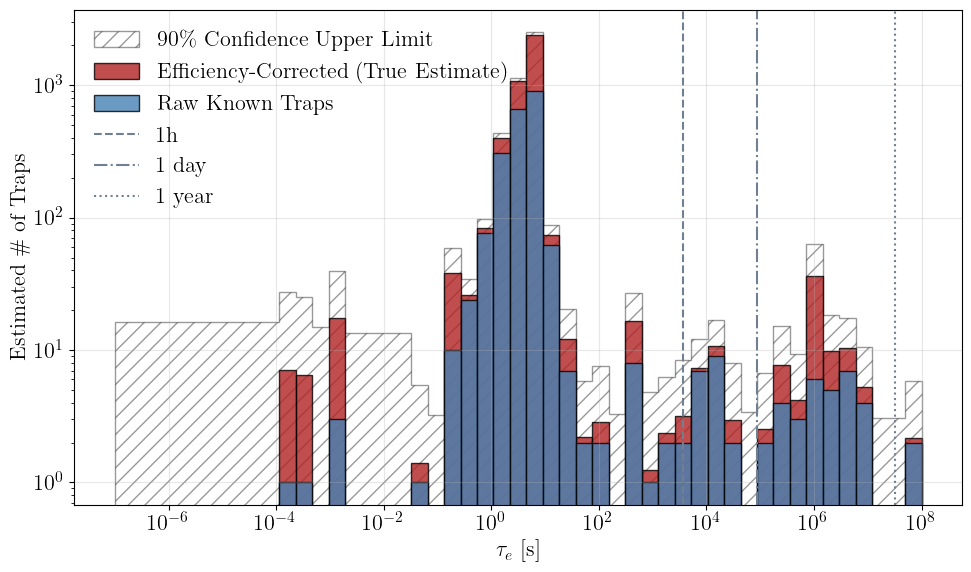

In [37]:


plt.figure(figsize=(10,6))

# 1. Load the bins from your saved file
tau_data = np.load('tau_at_135k_hist.npz')
tau_values = tau_data['bin_edges']
bins = tau_values
bin_centers = np.sqrt(bins[:-1] * bins[1:])

# 2. Reconstruct the raw and weighted histograms from your lists
raw_hist, _ = np.histogram(tau_target_list, bins=bins)
weighted_hist, _ = np.histogram(tau_target_list, bins=bins, weights=weights_list)

# 3. Calculate Effective Efficiency per bin (Raw / Weighted)
effective_efficiency = np.zeros_like(raw_hist, dtype=float)
valid = weighted_hist > 0
effective_efficiency[valid] = raw_hist[valid] / weighted_hist[valid]

# 4. Interpolate efficiency for empty bins (0 counts) so the upper limit doesn't break
if np.any(valid):
    eff_interp = interp1d(
        bin_centers[valid], 
        effective_efficiency[valid], 
        kind='nearest',        # 'nearest' works well for step-like distributions
        bounds_error=False, 
        fill_value="extrapolate"
    )
    effective_efficiency[~valid] = eff_interp(bin_centers[~valid])

# 5. Calculate Corrected Upper Limits using your Poisson/Gamma function
corrected_upper_limits = calculate_corrected_upper_limits(
    raw_hist, 
    effective_efficiency, 
    confidence_level=0.90
)

# ==========================================
# 6. Plotting
# ==========================================

# Plot Corrected Estimate
# Plot the 90% Upper Limit as a stepped line hovering above the data
plt.stairs(corrected_upper_limits, tau_values, 
           label="90\% Confidence Upper Limit", 
           color='black', alpha=0.4, lw=1,ls='-',fill=False, hatch='//')

plt.hist(tau_target_list, bins=bins, weights=weights_list, 
         color='firebrick', 
         label='Efficiency-Corrected (True Estimate)', edgecolor='black',alpha=0.8)

# Plot Raw Data
plt.hist(tau_target_list, bins=bins, color='steelblue', edgecolor='black', 
         alpha=0.8, label='Raw Known Traps')



# plt.title("Emission $\\tau_e$ at 135K with Poisson Upper Limits", fontsize=16)
plt.xlabel('$\\tau_e$ [s]', fontsize=small)
plt.ylabel('Estimated \# of Traps', fontsize=small)

plt.axvline(3600, label='1h', ls='--', color='slategrey')
plt.axvline(3600*24, label='1 day', ls='-.', color='slategrey')
plt.axvline(3600*24*365, label='1 year', ls=':', color='slategrey')

plt.legend(frameon=False, fontsize=small)
plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.savefig('figures/tau_at_135k_hist_upper_limit.pdf',dpi=300)
plt.show()
plt.close()


In [18]:
t = 135
filename = f'tau_at_{t}k_hist_upper_limit.npz'
np.savez(filename, 
            hist=corrected_upper_limits,           # Loaded as 'tau_weights' in run_ccd_simulation.py
            bin_edges=tau_values,)            # Loaded as 'tau_edges' in run_ccd_simulation.py
            # measured_taus=measured_taus,
            # extrapolated_taus=extrapolated_taus,
            # total_taus=total_taus,
            # meas_counts=meas_counts,
            # extrap_counts=extrap_counts,
            # efficiency=efficiency,
            # eff_err=eff_err)

In [87]:

def plot_simulation_results(rundir,mask='Halo+Bleed+HotColumn+HotPixel',showPlots=True):
    
    UR_expdep = 4.36e-5 #e / pix / day

    UR_expindep = 9.94e-5 #e / superpix / image

    UR_expdep = UR_expdep / (24) #e / pix / hour

    UR_expindep = UR_expindep#/ 32 #e / pix / image

    #bins for histogram
    lower_exp0 = 7e-5
    upper_exp0 = 2e-4

    lower_exp4 = 7e-5
    upper_exp4 = 2e-4



    lower_exp6 = 7e-5
    upper_exp6 = 2e-4


    lower_exp10 = 7e-5
    upper_exp10 = 2e-4


    lower_exp20 = 7e-5
    upper_exp20 = 2e-4

    nbins = 25

    num_images = len(os.listdir(rundir))

    total_counts_traps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
    total_pix_traps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}

    total_counts_notraps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
    total_pix_notraps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
    # lower = np.min(densities_exp)
    histograms = {
        0: Hist(hist.axis.Regular(nbins, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
        4: Hist(hist.axis.Regular(nbins, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
        6: Hist(hist.axis.Regular(nbins, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
        10: Hist(hist.axis.Regular(nbins, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
        20: Hist(hist.axis.Regular(nbins, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

    }

    histograms_no_traps = {
        0: Hist(hist.axis.Regular(nbins, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
        4: Hist(hist.axis.Regular(nbins, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
        6: Hist(hist.axis.Regular(nbins, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
        10: Hist(hist.axis.Regular(nbins, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
        20: Hist(hist.axis.Regular(nbins, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

    }

    plot = False

    colorlist = ['darkslategrey','rebeccapurple','dodgerblue','gold','firebrick']

    for i in range(num_images):
        with open(f'{rundir}ccd_traps_run{i}.pkl','rb') as f:
            ccd_run = pickle.load(f)
            # print(ccd_run.stats_trap.keys())

            

            unique_exposures = np.unique( np.sort(np.array(ccd_run.exposures)))

            if plot:
                fig,ax = plt.subplots(3,figsize=(10,12))
                fig.suptitle(f"CCD Run {i+1}")
                ax[0].set_ylabel('Masked 1e Counts')
                ax[1].set_ylabel('Unmasked Pixels')
                ax[2].set_ylabel('Unmasked 1e Counts')


            # ax[0,1].set_ylabel('Masked 1e Counts No Traps')
            # ax[1,1].set_ylabel('Unmasked Pixels No Traps')
            # ax[2,1].set_ylabel('Unmasked 1e Counts No Traps')

            for e in range(len(unique_exposures)):
                exp = unique_exposures[e]
                expkey = int(exp / 3600)
                # print(expkey)
                exp_indices = np.array(ccd_run.exposures) == exp

                # densities_exp = densities[exp_indices]
                # densities_exp_notraps = densities_notraps[exp_indices]


                counts = np.array(ccd_run.stats_trap[mask]['counts'])[exp_indices]
                counts_notraps = np.array(ccd_run.stats_notrap[mask]['counts'])[exp_indices]


                if mask == 'None':
                    unmasked_pix = unmasked_pix_notraps = int(1024 /2) * int(6144 / 2)
                    counts_masked = counts
                    counts_masked_notraps = counts_notraps


                
                else:

                    counts_masked = np.array(ccd_run.stats_trap[mask]['counts'])[exp_indices]
                    unmasked_pix = np.array(ccd_run.stats_trap[mask]['unmasked_pix'])[exp_indices]


                    counts_masked_notraps = np.array(ccd_run.stats_notrap[mask]['counts'])[exp_indices]
                    unmasked_pix_notraps = np.array(ccd_run.stats_notrap[mask]['unmasked_pix'])[exp_indices]

                


                # counts_masked = np.array(ccd_run.single_e_counts_masked)[exp_indices]
                # counts = np.array(ccd_run.single_e_counts)[exp_indices]
                # unmasked_pix = np.array(ccd_run.unmasked_pixels)[exp_indices]

                # counts_masked_notraps = np.array(ccd_run.single_e_counts_masked_no_traps)[exp_indices]
                # counts_notraps = np.array(ccd_run.single_e_counts_no_traps)[exp_indices]

                # unmasked_pix_notraps = np.array(ccd_run.unmasked_pixels_no_traps)[exp_indices]

                densities_exp = counts_masked / unmasked_pix

                densities_exp_notraps = counts_masked_notraps / unmasked_pix_notraps



                if plot:
                    ax[0].plot(counts_masked,label=f"{expkey}h Traps",color=colorlist[e])
                    ax[0].plot(counts_masked,label=f"{expkey}h No Traps",ls='--',color=colorlist[e])

                    ax[1].plot(unmasked_pix,label=f"{expkey}h Traps",color=colorlist[e])
                    ax[1].plot(unmasked_pix_notraps,label=f"{expkey}h No Traps",ls='--',color=colorlist[e])

                    ax[2].plot(counts,label=f"{expkey}h Traps",color=colorlist[e])
                    ax[2].plot(counts_notraps,label=f"{expkey}h No Traps",ls='--',color=colorlist[e])
                

                # print(f"Exposure: {expkey}h")

                # print("Max: ", np.max(densities_exp))
                # print("Min: ", np.min(densities_exp))


                total_counts_traps[expkey] += np.sum(counts_masked)
                total_pix_traps[expkey] += np.sum(unmasked_pix)

                total_counts_notraps[expkey] += np.sum(counts_masked_notraps)
                total_pix_notraps[expkey] += np.sum(unmasked_pix_notraps)
                
                # mean_traps[expkey].append(np.sum(counts_masked) / np.sum(unmasked_pix))

                # mean_traps_err[expkey].append(np.sqrt(np.sum(counts_masked)) / np.sum(unmasked_pix))

                # mean_notraps[expkey].append(np.sum(counts_masked_notraps) / np.sum(unmasked_pix_notraps))
                # mean_notraps_err[expkey].append(np.sqrt(np.sum(counts_masked_notraps))/ np.sum(unmasked_pix_notraps))

                histograms[expkey].fill(densities_exp)
                histograms_no_traps[expkey].fill(densities_exp_notraps)
            if plot:
                ax[0].legend()
                ax[1].legend()
                ax[2].legend()
                plt.tight_layout()
                plt.show()
                plt.close()
            del ccd_run
    colorlist = ['firebrick','seagreen','steelblue','orchid','darkviolet']
    if showPlots:
        fig, ax = plt.subplots(2,figsize=(12,12))
        for i in range(2):
            if i == 0:
                hists = histograms
                t = 'with'
            elif i == 1:
                hists = histograms_no_traps
                t = 'without'
            for j,h in enumerate([0,4,6,10,20]):
                color = colorlist[j]
                plothist = hists[h] #/ np.sum(hists[h].values())

                plothist.plot1d(ax=ax[i],color=color,label=f'{h}h')
            # hists[4].plot1d(ax=ax[i],color='seagreen',label='4h')
            # hists[6].plot1d(ax=ax[i],color='steelblue',label='6h')
            # hists[10].plot1d(ax=ax[i],color='orchid',label='10h')
            # hists[20].plot1d(ax=ax[i],color='darkviolet',label='20h')

            # ax[i].set_ylim(50)
            ax[i].set_title(f"{t} traps")
            ax[i].set_ylabel("NormalizedCounts")
            ax[i].set_xlabel("1e Densities")
            ax[i].legend()
        plt.tight_layout()
        plt.show()
        plt.close()

    unique_exposures_h = unique_exposures / 3600
    unique_exposures_h = unique_exposures_h.astype(int)



    average_densities = []
    average_density_errs = []
    average_densities_notraps = []
    average_density_errs_notraps = []

    for h in unique_exposures_h:
        # Traps: Mean = Total Counts / Total Pixels
        mean_t = total_counts_traps[h] / total_pix_traps[h]
        # Poisson Error = sqrt(Total Counts) / Total Pixels
        err_t = np.sqrt(total_counts_traps[h]) / total_pix_traps[h]
        
        average_densities.append(mean_t)
        average_density_errs.append(err_t)

        # No Traps
        mean_nt = total_counts_notraps[h] / total_pix_notraps[h]
        err_nt = np.sqrt(total_counts_notraps[h]) / total_pix_notraps[h]
        
        average_densities_notraps.append(mean_nt)
        average_density_errs_notraps.append(err_nt)

    average_densities = np.array(average_densities)
    average_density_errs = np.array(average_density_errs)
    average_densities_notraps = np.array(average_densities_notraps)
    average_density_errs_notraps = np.array(average_density_errs_notraps)






    # days = unique_exposures_h.reshape((-1, 1))

    popt, pcov = curve_fit(linear_func, unique_exposures_h, average_densities, sigma=average_density_errs, absolute_sigma=True)
    exp_dep, exp_indep = popt

    errors = np.sqrt(np.diag(pcov))

    err_dep = errors[0]
    err_indep = errors[1]





    popt, pcov = curve_fit(linear_func, unique_exposures_h, average_densities_notraps, sigma=average_density_errs_notraps, absolute_sigma=True)

    errors_notraps = np.sqrt(np.diag(pcov))

    err_dep_notraps = errors_notraps[0]
    err_indep_notraps = errors_notraps[1]

    # model_notraps = LinearRegression().fit(days, average_densities_notraps)

    # exp_indep_notraps = model_notraps.intercept_
    # exp_dep_notraps = model_notraps.coef_[0]

    exp_dep_notraps, exp_indep_notraps = popt


    hours = np.linspace(0,20,20)




    fit_no_traps = linear_func(hours,exp_dep_notraps,exp_indep_notraps)
    fit_traps = linear_func(hours,exp_dep,exp_indep)


    # plt.figure(figsize=(12,6))
    # ax = plt.gca()
    fig,axes = plt.subplots(2,figsize=(9,9),gridspec_kw={'height_ratios': [3, 1]})
    ax= axes[0]
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0)) # Forces scientific notation for all values
    ax.yaxis.set_major_formatter(formatter)

    # ax.scatter(unique_exposures_h,average_densities,color='firebrick',s=10)
    # ax.scatter(unique_exposures_h,average_densities_notraps,color='steelblue',s=10)

    ax.plot(hours,fit_traps,color='firebrick',alpha=0.4)
    ax.plot(hours,fit_no_traps,color='steelblue',alpha=0.4)

    ax.errorbar(unique_exposures_h,average_densities,yerr=average_density_errs,label='with Traps',color='firebrick',ls='None',marker='o',markersize=5,capsize=1)
    ax.errorbar(unique_exposures_h,average_densities_notraps,yerr=average_density_errs_notraps,label='without Traps',color='steelblue',ls='None',marker='o',markersize=5,capsize=1)
    ax.set_ylabel("Single Electron Density [e/unmasked pix]")
    ax.set_xlabel("Time [hours]")







    exp_indep_p = format_sci(exp_indep)

    exp_dep_p = format_sci(exp_dep)

    exp_indep_notraps_p = format_sci(exp_indep_notraps) 

    exp_dep_notraps_p = format_sci(exp_dep_notraps)

    UR_expindep_p = format_sci(UR_expindep)

    UR_expdep_p = format_sci(UR_expdep)


    true_rate = linear_func(hours,UR_expdep,UR_expindep)

    ax.plot(hours,true_rate,label='Truth',color='black',ls='--')



    # print("With Traps")
    # print(f'exposure independent: {exp_indep_p}')
    # print(f'exposure dependent: {exp_dep_p}')


    # print("Without Traps")
    # print(f'exposure independent: {exp_indep_notraps_p} e/pix/image')
    # print(f'exposure dependent: {exp_dep_notraps_p} e/pix/hour')

    # print("True Parameters")
    # print(f'exposure independent: {UR_expindep_p} e/pix/image ')
    # print(f'exposure dependent: {UR_expdep_p} e/pix/h')



    ax.text(
        x=0.99,
        y=0.30,
        s=f'Input Exposure Independent:  {UR_expindep_p}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=small,
        color='black'
    )

    ax.text(
        x=0.99,
        y=0.26,
        s=f'Input Exposure Dependent:  {UR_expdep_p}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=small,
        color='black'
    )



    ax.text(
        x=0.99,
        y=0.2,
        s=f'Exposure Independent with Traps:  {exp_indep_p}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=small,
        color='firebrick'
    )

    ax.text(
        x=0.99,
        y=0.16,
        s=f'Exposure Dependent with Traps:  {exp_dep_p}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=small,
        color='firebrick'
    )

    ax.text(
        x=0.99,
        y=0.10,
        s=f'Exposure Independent without Traps:  {exp_indep_notraps_p}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=small,
        color='steelblue'
    )

    ax.text(
        x=0.99,
        y=0.06,
        s=f'Exposure Dependent without Traps:  {exp_dep_notraps_p}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=small,
        color='steelblue'
    )

    ax.legend(frameon=False)

    # axes[1].errorbar(ls=None)
    # axes[1].scatter(unique_exposures_h,average_densities/average_densities,color='firebrick',s=10)
    diff = average_densities-average_densities_notraps
    # axes[1].scatter(unique_exposures_h,diff,color='black')
    maxdiff = np.max(diff)
    minval = maxdiff *-1

    properr = np.sqrt(np.sum(np.square([average_density_errs,average_densities_notraps]),axis=0))
    differr = np.sqrt(average_density_errs**2 + average_density_errs_notraps**2)
    # print(properr)
    # fig.suptitle(f"Masks Applied: {mask}",fontsize=large)
    axes[1].errorbar(unique_exposures_h,average_densities-average_densities_notraps,yerr = differr, color='black',ls="None",marker='o',capsize=3)
    # axes[1].set_ylim(minval,maxdiff*1.5)
    axes[1].set_ylabel("Difference")
    axes[1].axhline(0,ls='dashed',color='slategrey')
    axes[1].minorticks_on()
    axes[0].minorticks_on()
    # axes[0].grid()
    axes[0].set_xticks(np.arange(0,22,2))
    plt.tight_layout()
    runname = rundir.replace('/','')
    runname = runname.replace(".",'')
    # axes[0].set_title(runname)
    
    plt.savefig(f'figures/{runname}_sim_results.pdf',dpi=300)
    if showPlots:
        plt.show()
    plt.close()



    # Define the layout using a mosaic of characters
    # 'A', 'B', 'C' are the top three plots
    # '.' represents an empty space
    # 'D', 'E' are the bottom two, spanning two "virtual" columns each
    mosaic = """
    AABBCC
    .DDEE.
    """

    mosaic = """
    AABB
    CCDD
    EEFF
    """

    fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(15, 15), constrained_layout=True)
    key_list = ['A','B','C','D','E','F']
    # Plot data on each axis
    for i in range(len(average_densities)):
        key =key_list[i]
        
        # else:
        truth = linear_func(unique_exposures_h[i],UR_expdep,UR_expindep)
        ax_dict[key].errorbar(unique_exposures_h[i],average_densities[i],yerr=average_density_errs[i],label='with Traps',color='firebrick',capsize=3,marker='o',markersize=5)
        # ax_dict[key].scatter(unique_exposures_h[i],average_densities[i],color='firebrick')
        ax_dict[key].errorbar(unique_exposures_h[i],average_densities_notraps[i],yerr=average_density_errs_notraps[i],label='without Traps',color='steelblue',capsize=3,marker='o',markersize=5)
        # ax_dict[key].scatter(unique_exposures_h[i],average_densities_notraps[i],color='steelblue')
        ax_dict[key].scatter(unique_exposures_h[i],truth,color='black',label='Truth')
        ax_dict[key].legend()
        ax_dict[key].set_title(f"Exposure: {unique_exposures_h[i]}h")
        ax_dict[key].minorticks_on()

    # if key == 'F':
    key = 'F' 

    diff_err = np.sqrt(average_density_errs**2 + average_density_errs_notraps**2)
    ax_dict[key].errorbar(unique_exposures_h,diff,yerr=diff_err,marker='o',capsize=3,color='black',ls="None")
    ax_dict[key].set_ylabel(f"Differences")
    ax_dict[key].set_xlabel("Exposure [h]")
    ax_dict[key].minorticks_on()


    if showPlots:
        plt.show()
    plt.close()

    return (exp_indep, exp_dep, exp_indep_notraps, exp_dep_notraps, UR_expindep, UR_expdep, 
            err_indep, err_dep, err_indep_notraps, err_dep_notraps)
        




            
            

In [88]:
rundir = './minos_conditions/'
rundir = './minos_conditions_binned/'
rundir = './minos_conditions_upperlimit/'
rundir = './minos_conditions_binned_upperlimit/'
rundir = './snolab_conditions/'
rundir = './snolab_conditions_binned/'
rundir = './snolab_conditions_upperlimit/'
rundir = './snolab_conditions_binned_upperlimit/'

# run_directories_minos = ['./minos_conditions/','./minos_conditions_binned/','minos_conditions_upperlimit/','minos_conditions_binned_upperlimit/']
# run_directories_snolab = ['./snolab_conditions/','./snolab_conditions_binned/','snolab_conditions_upperlimit/','snolab_conditions_binned_upperlimit/']
run_directories_minos = ['./minos_conditions/','minos_conditions_upperlimit/']
run_directories_snolab = ['./snolab_conditions/','snolab_conditions_upperlimit/']
# mask = "None"
# mask = 'Halo'
# # mask = 'Halo+Bleed'
# # mask = "Halo+Bleed+HotPixel"
# # mask = "Halo+Bleed+HotColumn"
# mask = 'Halo+Bleed+HotColumn+HotPixel
minos_results = []
snolab_results = []
minos_results = []
snolab_results = []

for rm in run_directories_minos:
    results = plot_simulation_results(rm, mask='Halo+Bleed+HotColumn+HotPixel',showPlots=False)
    minos_results.append(results)

for rs in run_directories_snolab:
    results = plot_simulation_results(rs, mask='Halo+Bleed+HotColumn+HotPixel',showPlots=False)
    snolab_results.append(results)

# Convert to arrays: they will now have 10 columns instead of 6
m_res = np.array(minos_results)
s_res = np.array(snolab_results)



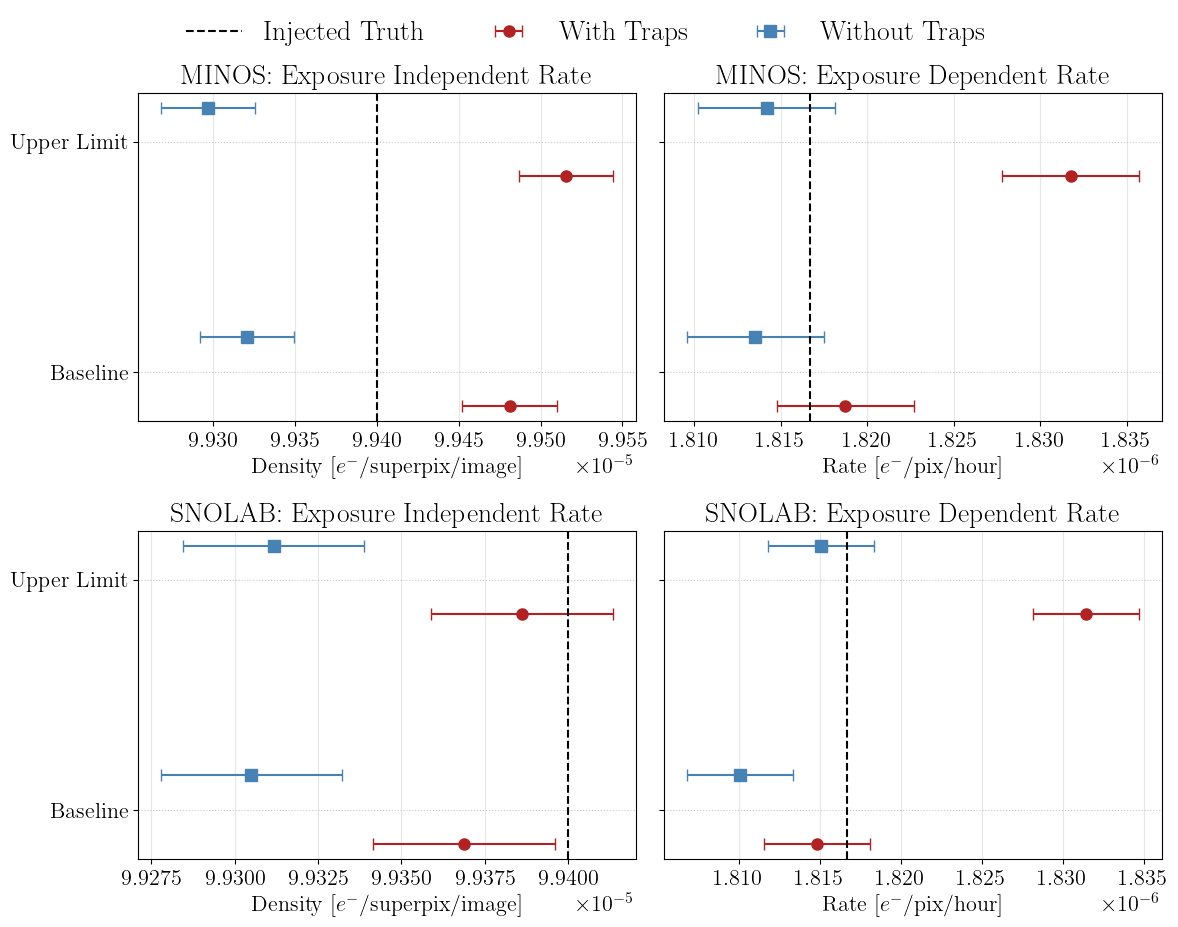

In [ ]:

labels = ['Baseline', 'Upper Limit']
# labels = ['Baseline', 'Binned', 'Upper Limit', 'Binned + UL']
y_pos = np.arange(len(labels))



fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
fig.subplots_adjust(wspace=0.1, hspace=0.3)

# Formatting helper for scientific notation
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

# 3. Plotting Function
# 1. Update the function definition to accept error columns
def plot_forest(ax, data, col_indep, col_notraps, col_truth, col_err_traps, col_err_notraps, title, xlabel):
    offset = 0.15 
    
    ax.errorbar(data[:, col_indep], y_pos - offset, xerr=data[:, col_err_traps], 
                fmt='o', color='firebrick', label='With Traps', markersize=8, capsize=4)
    
    ax.errorbar(data[:, col_notraps], y_pos + offset, xerr=data[:, col_err_notraps], 
                fmt='s', color='steelblue', label='Without Traps', markersize=8, capsize=4)
    
    truth_val = data[0, col_truth]
    ax.axvline(x=truth_val, color='black', linestyle='--', linewidth=1.5, label='Injected Truth')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=small)
    ax.invert_yaxis()
    
    ax.set_title(title, fontsize=medium, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=small)
    
    # Make sure to keep your scientific formatter here!
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)
    
    ax.grid(True, axis='y', linestyle=':', alpha=0.7)
    ax.grid(True, axis='x', linestyle='-', alpha=0.3)


# --- ROW 1: MINOS ---
# Intercepts: Traps=0, NoTraps=2, Truth=4, ErrTraps=6, ErrNoTraps=8
plot_forest(axes[0, 0], m_res, 0, 2, 4, 6, 8,
            title="MINOS: Exposure Independent Rate", xlabel=r"Density [$e^-$/superpix/image]")

# Slopes: Traps=1, NoTraps=3, Truth=5, ErrTraps=7, ErrNoTraps=9
plot_forest(axes[0, 1], m_res, 1, 3, 5, 7, 9,
            title="MINOS: Exposure Dependent Rate", xlabel=r"Rate [$e^-$/pix/hour]")

# --- ROW 2: SNOLAB ---
plot_forest(axes[1, 0], s_res, 0, 2, 4, 6, 8,
            title="SNOLAB: Exposure Independent Rate", xlabel=r"Density [$e^-$/superpix/image]")

plot_forest(axes[1, 1], s_res, 1, 3, 5, 7, 9,
            title="SNOLAB: Exposure Dependent Rate", xlabel=r"Rate [$e^-$/pix/hour]")

# 4. Global Legend and Final Polish
# We only need one legend for the whole figure since they all share the same style
handles, plot_labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, plot_labels, loc='upper center', ncol=3, fontsize=medium, frameon=False, bbox_to_anchor=(0.5, 1.05))

plt.show()
plt.savefig('figures/results_comparison.pdf',dpi=300)